# PRICING DINÁMICO DE HABITACIONES DE HOTEL

*Cristian Rubio Barato*

*Francisco Martínez Esteso*

*José Vicente García López*

*Víctor Ortega Gómez*


## ÍNDICE

1. [PREPROCESAMIENTO](#1-preprocesamiento)    
   1.1 [Instalar MLRun](#11-instalar-mlrun)   
   1.2 [Crear proyecto](#12-crear-proyecto)   
   1.3 [Preprocesamiento dataset](#13-preprocesamiento-dataset)   

2. [ENTRENAMIENTO](#2-entrenamiento)  
   2.1 [Funcion entrenamiento](#21-funcion-entrenamiento)   
   2.2 [Resumen entrenamiento](#22-resumen-entrenamiento)   

3. [DESPLIEGUE E INFERENCIA](#3-despliegue-e-inferencia)  

In [18]:
random_state = 27912

## 1. PREPROCESAMIENTO

### 1.1 Instalar MLRun

In [ ]:
# Install MLRun and sklearn, run this only once (restart the notebook after the install !!!)
%pip install mlrun scikit-learn~=1.5.1 numpy~=1.26.4

### 1.2 Crear proyecto

In [2]:
import mlrun

In [3]:
project = mlrun.get_or_create_project("pricing-hotel", "./", user_project=True)

> 2025-04-23 17:14:35,098 [info] Project loaded successfully: {"project_name":"pricing-hotel-jovyan"}


### 1.3 Preprocesamiento dataset

In [4]:
%%writefile hotel_prep.py

from datetime import datetime
import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import mlrun

@mlrun.handler(outputs=["dataset", "label_column"])
def hotel_booking_preprocessor(context):
    df = pd.read_csv('hotel_booking.csv')
    
    df = df.dropna(subset=["adr"])
    df.fillna(0, inplace=True)
    
    df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])
    df["reservation_status_year"]  = df["reservation_status_date"].dt.year
    df["reservation_status_date"]  = df["reservation_status_date"].dt.date
    df["arrival_date_month"]       = pd.to_datetime(df["arrival_date_month"], format="%B").dt.month
    df["children"] = df["children"].astype(int)
    
    start_date = datetime.strptime("2015-07", "%Y-%m").date()
    df = df[df['reservation_status_date'] >= start_date]
    
    columns_to_drop = [
        "days_in_waiting_list", "name", "email", "phone-number",
        "credit_card", "agent", "company", "booking_changes",
        "arrival_date_week_number"
    ]
    df.drop(columns=columns_to_drop, inplace=True, errors="ignore")
    
    df = df[~((df["adults"] == 0) & (df["children"] == 0) & (df["babies"] == 0))]
    
    Q1 = np.percentile(df["adr"], 25)
    Q3 = np.percentile(df["adr"], 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df["adr"] >= lower_bound) & (df["adr"] <= upper_bound)]
    
    categorical_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()
    df = pd.get_dummies(df, columns=categorical_vars, drop_first=True)
    
    numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
    scaler = StandardScaler()
    df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
    
    joblib.dump(scaler, "scaler.pkl")  # guardar como archivo binario
    context.log_artifact("scaler", local_path="scaler.pkl") 
    
    return df, "adr"

Overwriting hotel_prep.py


In [5]:
# Registrar la función en MLRun
hotel_prep_fn = project.set_function(
    "hotel_prep.py",                  
    name="hotel-prep",                    
    kind="job",                           
    image="mlrun/mlrun",                 
    handler="hotel_booking_preprocessor"  
)

project.save()


In [6]:
hotel_pricing_run = project.run_function("hotel-prep", local=True)

> 2025-04-23 17:14:41,676 [warning] it is recommended to use k8s secret (specify secret_name), specifying the aws_access_key/aws_secret_key directly is unsafe
> 2025-04-23 17:14:41,699 [info] Storing function: {"db":"http://mlrun-api:8080","name":"hotel-prep-hotel-booking-preprocessor","uid":"f7621b80f6b6449f9e483cacd74e5af2"}


project,uid,iter,start,state,kind,name,labels,inputs,parameters,results,artifacts
pricing-hotel-jovyan,...d74e5af2,0,Apr 23 17:14:41,completed,run,hotel-prep-hotel-booking-preprocessor,kind=localowner=jovyanhost=mlrun-jupyter-84d9487f79-hjmm8,,,label_column=adr,scalerdataset


> 2025-04-23 17:14:47,493 [info] Run execution finished: {"name":"hotel-prep-hotel-booking-preprocessor","status":"completed"}


In [7]:
hotel_pricing_run.state()

'completed'

In [8]:
hotel_pricing_run.outputs

{'label_column': 'adr',
 'scaler': 'store://artifacts/pricing-hotel-jovyan/hotel-prep-hotel-booking-preprocessor_scaler:latest@f7621b80f6b6449f9e483cacd74e5af2',
 'dataset': 'store://datasets/pricing-hotel-jovyan/hotel-prep-hotel-booking-preprocessor_dataset:latest@f7621b80f6b6449f9e483cacd74e5af2'}

## 2. ENTRENAMIENTO

### 2.1 Funcion entrenamiento

In [9]:
trainer = mlrun.import_function("hub://auto_trainer")

In [10]:
metrics = {
    "R2": "sklearn.metrics.r2_score",
    "MAE": "sklearn.metrics.mean_absolute_error",
    "MSE": "sklearn.metrics.mean_squared_error",
    "RMSE": "sklearn.metrics.root_mean_squared_error",
    "Max Error": "sklearn.metrics.max_error"
}

# Ejecutamos el paso de entrenamiento con:
trainer_run = project.run_function(
    trainer,
    handler="train",
    inputs={"dataset": hotel_pricing_run.outputs["dataset"]},
    params={
        "model_class": "sklearn.ensemble.RandomForestRegressor",
        "train_test_split_size": 0.2,
        "label_columns": "adr",
        "model_name": "hotel_price_rf",
        # Le decimos al auto_trainer qué métricas calcular
        "_metrics": metrics,  
    },
    # Ponemos los mejores hiperparámetros (los que seleccionamos en el hito 3):
    hyperparams={
        "n_estimators": [100],
        "max_depth": [None],
        "min_samples_split": [5],
    },
    selector="max.R2",
    local=True
)

> 2025-04-23 17:14:56,892 [warning] it is recommended to use k8s secret (specify secret_name), specifying the aws_access_key/aws_secret_key directly is unsafe
> 2025-04-23 17:14:56,921 [info] Storing function: {"db":"http://mlrun-api:8080","name":"auto-trainer-train","uid":"e5e5a839ca2a429ea26a3a78c3fa8fe2"}
> 2025-04-23 17:14:57,658 [info] Sample set not given, using the whole training set as the sample set
> 2025-04-23 17:14:58,947 [info] training 'hotel_price_rf'


/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.

/opt/conda/lib/python3.9/site-packages/mlrun/data_types/infer.py:143: RuntimeWarning:

Converting input from bool to <class 'numpy.uint8'> for compatibility.



> 2025-04-23 17:23:34,955 [info] best iteration=1, used criteria max.R2


project,uid,iter,start,state,kind,name,labels,inputs,parameters,results,artifacts
pricing-hotel-jovyan,...c3fa8fe2,0,Apr 23 17:14:57,completed,run,auto-trainer-train,kind=localowner=jovyan,dataset,"model_class=sklearn.ensemble.RandomForestRegressortrain_test_split_size=0.2label_columns=adrmodel_name=hotel_price_rf_metrics={'R2': 'sklearn.metrics.r2_score', 'MAE': 'sklearn.metrics.mean_absolute_error', 'MSE': 'sklearn.metrics.mean_squared_error', 'RMSE': 'sklearn.metrics.root_mean_squared_error', 'Max Error': 'sklearn.metrics.max_error'}",best_iteration=1R2=0.8624903986515422MAE=0.19024266125878303MSE=0.13819108976062475RMSE=0.3717406216175799Max Error=4.19635039331018mean_absolute_error=0.19024266125878303r2_score=0.8624903986515422root_mean_squared_error=0.3717406216175799mean_squared_error=0.13819108976062475,feature-importancetest_setmodeliteration_resultsparallel_coordinates


> 2025-04-23 17:23:39,749 [info] Run execution finished: {"name":"auto-trainer-train","status":"completed"}


### 2.2 Resumen entrenamiento

In [11]:
trainer_run.outputs

{'best_iteration': 1,
 'R2': 0.8624903986515422,
 'MAE': 0.19024266125878303,
 'MSE': 0.13819108976062475,
 'RMSE': 0.3717406216175799,
 'Max Error': 4.19635039331018,
 'mean_absolute_error': 0.19024266125878303,
 'r2_score': 0.8624903986515422,
 'root_mean_squared_error': 0.3717406216175799,
 'mean_squared_error': 0.13819108976062475,
 'feature-importance': 's3://mlrun/projects/pricing-hotel-jovyan/artifacts/auto-trainer-train/1/feature-importance.html',
 'test_set': 'store://datasets/pricing-hotel-jovyan/auto-trainer-train_test_set:latest@e5e5a839ca2a429ea26a3a78c3fa8fe2',
 'model': 'store://models/pricing-hotel-jovyan/hotel_price_rf:latest@e5e5a839ca2a429ea26a3a78c3fa8fe2',
 'iteration_results': 's3://mlrun/projects/pricing-hotel-jovyan/artifacts/auto-trainer-train/0/iteration_results.csv',
 'parallel_coordinates': 'store://artifacts/pricing-hotel-jovyan/auto-trainer-train_parallel_coordinates:latest@e5e5a839ca2a429ea26a3a78c3fa8fe2'}

## 3. DESPLIEGUE E INFERENCIA

In [12]:
serving_fn = project.set_function(
    func="",
    name="serving",
    image="mlrun/mlrun",
    kind="serving",
    requirements=["scikit-learn~=1.5.1"]
)

> 2025-04-23 17:23:46,498 [info] Function code not specified, setting entry point to image


In [13]:
serving_fn.add_model(
    "hotel-pricing-model",  
    model_path=trainer_run.outputs["model"],  
    class_name="mlrun.frameworks.sklearn.SklearnModelServer" 
)

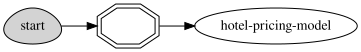

In [14]:
serving_fn.spec.graph.plot(rankdir="LR")

In [15]:
server = serving_fn.to_mock_server()

> 2025-04-23 17:23:52,333 [warning] run command, file or code were not specified
> 2025-04-23 17:23:55,531 [info] model hotel-pricing-model was loaded
> 2025-04-23 17:23:55,535 [info] Loaded ['hotel-pricing-model']


In [16]:
# Verificamos que el endpoint está listo
server.test("/v2/models/", method="GET")

{'models': ['hotel-pricing-model']}

In [19]:
import numpy as np
import pandas as pd

np.random.seed(27912)

# Como nuestro dataset después del preprocesamiento tiene 1167 columnas, 
# la inferencia la hacemos de forma aleatoria

dataset_uri = hotel_pricing_run.outputs["dataset"]

# Cargar el dataset en un DataFrame
df = mlrun.get_dataitem(dataset_uri).as_df()
X = df.drop(columns=['adr'])

# Usamos el mismo orden de columnas que en el dataset final
column_names = X.columns.tolist()
example_row = []

for col in X.dtypes.index:
    dtype = X.dtypes[col]

    if dtype == "bool":
        value = bool(np.random.randint(0, 2))  
    elif dtype == "int32" or dtype == "int64":
        value = int(np.random.randint(-2, 2))  
    elif dtype == "float64":
        value = float(np.random.normal(0, 1)) 
    else:
        value = 0

    example_row.append(value)

# Construimos el input que espera el modelo
example_input = {
    "inputs": [example_row]
}


In [20]:
response = server.test("/v2/models/hotel-pricing-model/infer", body=example_input)
print(response)

{'id': 'b87ac67447dc4146b9761c6e7a5b9670', 'model_name': 'hotel-pricing-model', 'outputs': [-1.0897791929289624], 'timestamp': '2025-04-23 17:25:53.193832+00:00'}


/opt/conda/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but RandomForestRegressor was fitted with feature names



In [21]:
project.deploy_function(serving_fn)

> 2025-04-23 17:25:59,215 [warning] it is recommended to use k8s secret (specify secret_name), specifying the aws_access_key/aws_secret_key directly is unsafe
> 2025-04-23 17:25:59,218 [info] Starting remote function deploy
2025-04-23 17:25:59  (info) Deploying function
2025-04-23 17:25:59  (info) Building
2025-04-23 17:25:59  (info) Staging files and preparing base images
2025-04-23 17:25:59  (warn) Using user provided base image, runtime interpreter version is provided by the base image
2025-04-23 17:25:59  (info) Building processor image
2025-04-23 17:43:00  (info) Build complete
2025-04-23 17:43:33  (info) Function deploy complete
> 2025-04-23 17:43:41,265 [info] Successfully deployed function: {"external_invocation_urls":["172.26.91.181:32574"],"internal_invocation_urls":["nuclio-pricing-hotel-jovyan-serving.mlrun.svc.cluster.local:8080"]}


DeployStatus(state=ready, outputs={'endpoint': 'http://172.26.91.181:32574', 'name': 'pricing-hotel-jovyan-serving'})

In [22]:
response = serving_fn.invoke("/v2/models/hotel-pricing-model/infer", body=example_input)

print("Predicción del precio (adr):", response)

> 2025-04-23 17:45:06,363 [info] Invoking function: {"method":"POST","path":"http://nuclio-pricing-hotel-jovyan-serving.mlrun.svc.cluster.local:8080/v2/models/hotel-pricing-model/infer"}
Predicción del precio (adr): {'id': 'a7ea71be-69ff-463c-863e-a97f7812d3e9', 'model_name': 'hotel-pricing-model', 'outputs': [-1.0897791929289624], 'timestamp': '2025-04-23 17:45:06.395386+00:00', 'model_version': 'latest'}
